# 01 — Data Profiling

**Project:** Marketing Attribution & Systems-Integration Analysis

## Purpose of this notebook

Profile each source system **in isolation** before attempting any join.

This is deliberate. The temptation with two datasets is to immediately `pd.merge()` them and
start analysing. That approach hides the interesting problem. The interesting problem is that
these two systems were built by different teams, for different purposes, with different
vocabularies — and understanding *each system on its own terms* is what makes the eventual
integration failure legible.

**Rule for this notebook: no joins.** We only look at each dataset separately.

## Business framing

A marketing team buys ads across Google, Meta, and TikTok. A sales team tracks deals in a CRM.
Leadership asks a reasonable-sounding question:

> "Which ad channels are actually producing revenue?"

Answering it requires connecting ad spend to closed deals. This notebook establishes what we
have to work with before we discover why that connection is harder than it sounds.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set_theme(style='whitegrid')

print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 3.0.2
numpy: 2.4.4


---

# Part 1 — System A: Ad Platform Data

Source: *Global Ads Performance (Google, Meta, TikTok)*
File: `data/raw/ads_performance.csv`

This represents what the marketing team sees — data exported from ad platform dashboards.

In [2]:
ads = pd.read_csv('../data/raw/ads_performance.csv')

print("Shape:", ads.shape)
ads.head()

Shape: (1800, 14)


,date,platform,campaign_type,industry,country,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS
0,2024-01-21,Google Ads,Search,Fintech,UAE,59886,2113,0.0353,1.26,2662.38,159,16.74,4803.43,1.80
1,2024-01-22,TikTok Ads,Search,EdTech,UK,135608,5220,0.0385,1.18,6159.60,411,14.99,64126.68,10.41
2,2024-06-15,TikTok Ads,Video,Healthcare,USA,92313,5991,0.0649,0.85,5092.35,267,19.07,10489.07,2.06
3,2024-01-02,TikTok Ads,Shopping,SaaS,Germany,83953,5935,0.0707,1.32,7834.20,296,26.47,50505.07,6.45
4,2024-02-22,TikTok Ads,Search,Healthcare,UK,91807,4489,0.0489,1.93,8663.77,107,80.97,3369.53,0.39


In [3]:
ads.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1800 non-null   str    
 1   platform       1800 non-null   str    
 2   campaign_type  1800 non-null   str    
 3   industry       1800 non-null   str    
 4   country        1800 non-null   str    
 5   impressions    1800 non-null   int64  
 6   clicks         1800 non-null   int64  
 7   CTR            1800 non-null   float64
 8   CPC            1800 non-null   float64
 9   ad_spend       1800 non-null   float64
 10  conversions    1800 non-null   int64  
 11  CPA            1800 non-null   float64
 12  revenue        1800 non-null   float64
 13  ROAS           1800 non-null   float64
dtypes: float64(6), int64(3), str(5)
memory usage: 263.9 KB


### Column inventory

Two distinct kinds of column here, and the difference matters:

- **Dimensions** (what the row is *about*): `date`, `platform`, `campaign_type`, `industry`, `country`
- **Measures** (what we're *counting*): `impressions`, `clicks`, `ad_spend`, `conversions`, `revenue`
- **Derived measures** (computed from other measures): `CTR`, `CPC`, `CPA`, `ROAS`

Derived measures are worth flagging early: they must **never** be averaged directly when
aggregating. Averaging a ratio across rows gives the wrong answer. We recompute them from
summed components instead. This comes up in notebook 02.

In [4]:
# Cardinality of each dimension — tells us the grain
dims = ['date', 'platform', 'campaign_type', 'industry', 'country']

for c in dims:
    print(f"{c:<15} {ads[c].nunique():>5} unique")

print()
for c in ['platform', 'campaign_type', 'industry', 'country']:
    print(f"{c}: {sorted(ads[c].unique())}")

date              360 unique
platform            3 unique
campaign_type       4 unique
industry            5 unique
country             7 unique

platform: ['Google Ads', 'Meta Ads', 'TikTok Ads']
campaign_type: ['Display', 'Search', 'Shopping', 'Video']
industry: ['E-commerce', 'EdTech', 'Fintech', 'Healthcare', 'SaaS']
country: ['Australia', 'Canada', 'Germany', 'India', 'UAE', 'UK', 'USA']


### The grain question

> **One row in the ads dataset = ?**

Let's verify rather than assume. If the grain is
`date × platform × campaign_type × industry × country`, then that combination should be unique
across all rows.

In [5]:
grain_cols = ['date', 'platform', 'campaign_type', 'industry', 'country']

dupe_count = ads.duplicated(subset=grain_cols).sum()
print(f"Rows: {len(ads)}")
print(f"Unique {' × '.join(grain_cols)} combos: {ads[grain_cols].drop_duplicates().shape[0]}")
print(f"Duplicate combos: {dupe_count}")

# Full theoretical grid size, for comparison
grid = np.prod([ads[c].nunique() for c in grain_cols])
print(f"\nFull cross-product would be: {grid:,} rows")
print(f"Actual: {len(ads):,} rows  ({len(ads)/grid:.2%} of grid — sparse)")

Rows: 1800
Unique date × platform × campaign_type × industry × country combos: 1788
Duplicate combos: 12

Full cross-product would be: 151,200 rows
Actual: 1,800 rows  (1.19% of grid — sparse)


**Finding:** the dataset is a *sparse sample* of the possible dimension grid (~1.2% of it),
not a complete daily panel.

Note the 12 duplicate dimension combinations. The five dimensions are therefore **not** a strict
primary key — there is no column that makes those 12 rows distinguishable. They must be summed
when aggregating, never treated as separate entities. It is a small number, but worth knowing
about rather than discovering later.

**Implication:** we cannot treat this as a continuous daily time series per campaign. There is
no campaign that we can follow day-by-day through the year. Any time-based analysis has to
aggregate up to a coarser period.

In [6]:
# Data quality checks
print("=== Nulls ===")
print(ads.isnull().sum())

print("\n=== Fully duplicated rows ===")
print(ads.duplicated().sum())

print("\n=== Numeric sanity: any negatives or zeros where they'd be suspicious? ===")
num_cols = ['impressions', 'clicks', 'ad_spend', 'conversions', 'revenue']
print(ads[num_cols].describe().T[['min', 'max', 'mean']])

=== Nulls ===
date             0
platform         0
campaign_type    0
industry         0
country          0
impressions      0
clicks           0
CTR              0
CPC              0
ad_spend         0
conversions      0
CPA              0
revenue          0
ROAS             0
dtype: int64

=== Fully duplicated rows ===
0

=== Numeric sanity: any negatives or zeros where they'd be suspicious? ===
                 min        max           mean
impressions  5059.00  199650.00  102919.018889
clicks         91.00   16660.00    3962.675556
ad_spend       58.00   38453.32    6171.527272
conversions     2.00    1151.00     181.562222
revenue       142.69  295028.26   30101.850450


### Critical: is there a join key?

This is the question that determines whether this project is easy or interesting.

In [7]:
id_like = [c for c in ads.columns
           if any(k in c.lower() for k in ['id', 'key', 'code', 'campaign_name', 'utm'])]

print("Identifier-like columns in ads data:", id_like if id_like else "NONE")
print("\nAll columns:", list(ads.columns))

Identifier-like columns in ads data: NONE

All columns: ['date', 'platform', 'campaign_type', 'industry', 'country', 'impressions', 'clicks', 'CTR', 'CPC', 'ad_spend', 'conversions', 'CPA', 'revenue', 'ROAS']


**Finding — this is the central problem of the project:**

There is **no identifier column at all**. No `campaign_id`, no `campaign_name`, no `utm_source`,
no `customer_id`. The most granular thing identifying a row is the *combination* of its five
dimensions.

You cannot trace an individual ad click to an individual person, company, or deal. The data is
**pre-aggregated at the campaign-type level before it ever leaves the ad platform.**

This is not a flaw in the dataset — it is exactly how ad platform exports work in reality.
Platforms report aggregate performance; they do not hand over the identity of everyone who
clicked. This is the fundamental reason marketing attribution is hard.

In [8]:
# Date handling — currently strings
ads['date'] = pd.to_datetime(ads['date'])

print("Date range:", ads['date'].min().date(), "→", ads['date'].max().date())
print("Span:", (ads['date'].max() - ads['date'].min()).days, "days")
print("Distinct dates:", ads['date'].nunique())

Date range: 2024-01-01 → 2024-12-30
Span: 364 days
Distinct dates: 360


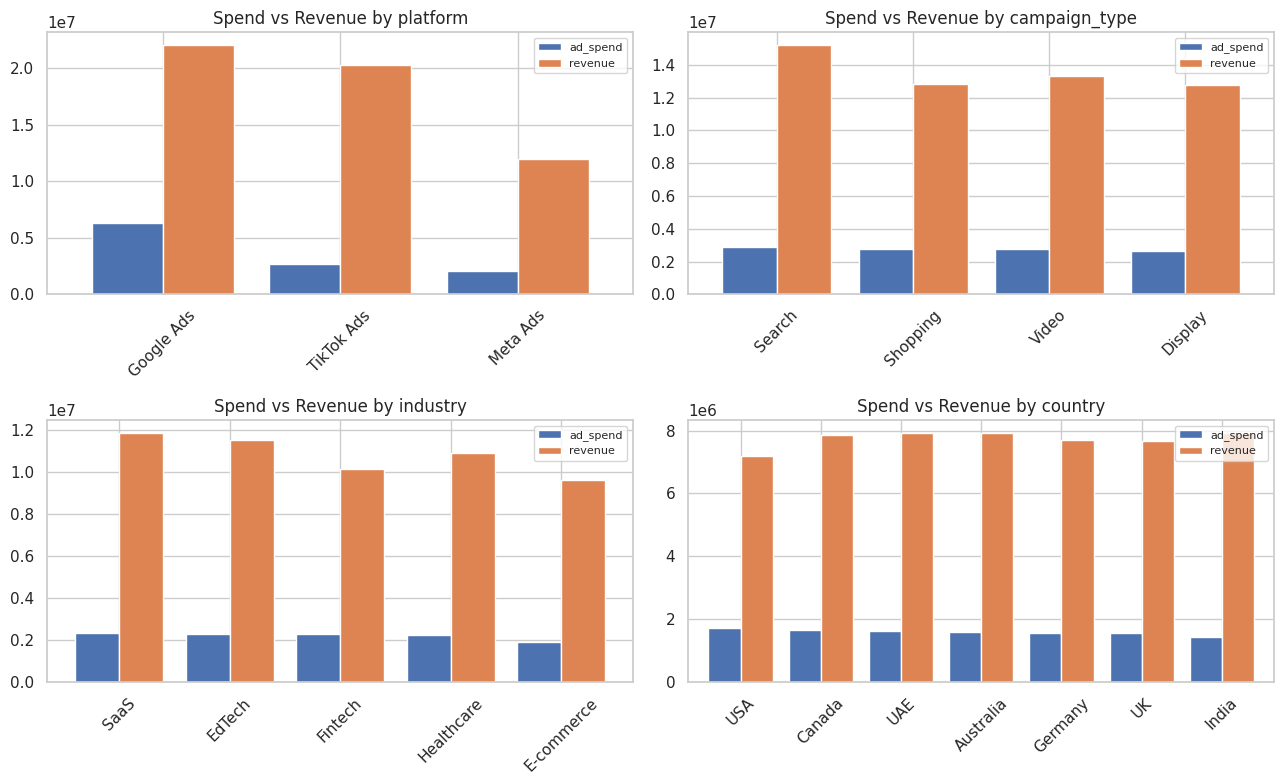

In [9]:
# Where does the money go? Spend and revenue by dimension
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, dim in zip(axes.flat, ['platform', 'campaign_type', 'industry', 'country']):
    agg = ads.groupby(dim)[['ad_spend', 'revenue']].sum().sort_values('ad_spend', ascending=False)
    agg.plot(kind='bar', ax=ax, width=0.8)
    ax.set_title(f'Spend vs Revenue by {dim}')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [10]:
# Correctly computed aggregate metrics (recomputed from sums, NOT averaged)
summary = ads.groupby('industry').agg(
    ad_spend=('ad_spend', 'sum'),
    revenue=('revenue', 'sum'),
    clicks=('clicks', 'sum'),
    impressions=('impressions', 'sum'),
    conversions=('conversions', 'sum'),
).assign(
    ROAS=lambda d: d['revenue'] / d['ad_spend'],
    CPA=lambda d: d['ad_spend'] / d['conversions'],
    CTR=lambda d: d['clicks'] / d['impressions'],
).round(3)

print("Ads performance by industry (metrics recomputed from summed components):")
summary

Ads performance by industry (metrics recomputed from summed components):


,ad_spend,revenue,clicks,impressions,conversions,ROAS,CPA,CTR
industry,,,,,,,,
E-commerce,1923987.08,9637279.69,1280139,33800712,57486,5.009,33.469,0.038
EdTech,2296978.52,11549934.43,1502152,39833845,67257,5.028,34.152,0.038
Fintech,2271537.73,10173311.23,1412347,36966664,65121,4.479,34.882,0.038
Healthcare,2258683.92,10930814.04,1387123,36619145,65687,4.839,34.386,0.038
SaaS,2357561.84,11891991.42,1551055,38033868,71261,5.044,33.083,0.041


### Why recomputing matters — a quick demonstration

Averaging the pre-computed `ROAS` column gives a different (and wrong) answer than dividing
total revenue by total spend. Worth showing explicitly, because this mistake is extremely
common and silently wrong.

In [11]:
naive_roas = ads.groupby('industry')['ROAS'].mean()
correct_roas = ads.groupby('industry').apply(
    lambda g: g['revenue'].sum() / g['ad_spend'].sum(), include_groups=False
)

comparison = pd.DataFrame({
    'naive_mean_of_ratios': naive_roas.round(3),
    'correct_ratio_of_sums': correct_roas.round(3),
})
comparison['pct_error'] = ((comparison['naive_mean_of_ratios'] / comparison['correct_ratio_of_sums'] - 1) * 100).round(1)
comparison

,naive_mean_of_ratios,correct_ratio_of_sums,pct_error
industry,,,
E-commerce,6.134,5.009,22.5
EdTech,6.829,5.028,35.8
Fintech,6.031,4.479,34.7
Healthcare,6.588,4.839,36.1
SaaS,6.648,5.044,31.8


---

# Part 2 — System B: CRM Sales Data

Source: *CRM Sales Opportunities*
Files: `data/raw/crm_sales_opps/` — `sales_pipeline.csv`, `accounts.csv`, `products.csv`, `sales_teams.csv`

This represents what the sales team sees. Note immediately that this is a **relational schema**
(multiple linked tables), whereas the ads data was a single flat file. That structural
difference is itself informative: the CRM was designed as a system of record; the ads export
was designed as a report.

In [12]:
crm_path = '../data/raw/crm_sales_opps/'

pipeline = pd.read_csv(crm_path + 'sales_pipeline.csv')
accounts = pd.read_csv(crm_path + 'accounts.csv')
products = pd.read_csv(crm_path + 'products.csv')
teams    = pd.read_csv(crm_path + 'sales_teams.csv')
data_dict = pd.read_csv(crm_path + 'data_dictionary.csv')

for name, df in [('sales_pipeline', pipeline), ('accounts', accounts),
                 ('products', products), ('sales_teams', teams)]:
    print(f"{name:<16} {str(df.shape):>12}   {list(df.columns)}")

sales_pipeline      (8800, 8)   ['opportunity_id', 'sales_agent', 'product', 'account', 'deal_stage', 'engage_date', 'close_date', 'close_value']
accounts              (85, 7)   ['account', 'sector', 'year_established', 'revenue', 'employees', 'office_location', 'subsidiary_of']
products               (7, 3)   ['product', 'series', 'sales_price']
sales_teams           (35, 3)   ['sales_agent', 'manager', 'regional_office']


In [13]:
# The dataset ships with its own data dictionary — always read it
data_dict

,Table,Field,Description
0,accounts,account,Company name
1,accounts,sector,Industry
2,accounts,year_established,Year Established
3,accounts,revenue,Annual revenue (in millions of USD)
4,accounts,employees,Number of employees
5,accounts,office_location,Headquarters
6,accounts,subsidiary_of,Parent company
7,products,product,Product name
8,products,series,Product series
9,products,sales_price,Suggested retail price


### The grain question, again

> **One row in `sales_pipeline` = ?**

The data dictionary says `opportunity_id` is a unique identifier. Let's verify — a stated
primary key that isn't actually unique is a classic source of silent double-counting.

In [14]:
print("Rows:", len(pipeline))
print("Unique opportunity_id:", pipeline['opportunity_id'].nunique())
print("Is opportunity_id a true primary key:", pipeline['opportunity_id'].is_unique)

print("\nOne row = one sales opportunity (deal), at its current state in the pipeline.")

Rows: 8800
Unique opportunity_id: 8800
Is opportunity_id a true primary key: True

One row = one sales opportunity (deal), at its current state in the pipeline.


In [15]:
pipeline.head()

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0


In [16]:
print("=== Nulls in sales_pipeline ===")
null_summary = pd.DataFrame({
    'nulls': pipeline.isnull().sum(),
    'pct': (pipeline.isnull().sum() / len(pipeline) * 100).round(1)
})
print(null_summary)

print("\n=== deal_stage distribution ===")
print(pipeline['deal_stage'].value_counts())

=== Nulls in sales_pipeline ===
                nulls   pct
opportunity_id      0   0.0
sales_agent         0   0.0
product             0   0.0
account          1425  16.2
deal_stage          0   0.0
engage_date       500   5.7
close_date       2089  23.7
close_value      2089  23.7

=== deal_stage distribution ===
deal_stage
Won            4238
Lost           2473
Engaging       1589
Prospecting     500
Name: count, dtype: int64


### Understanding the nulls — they are structural, not random

Nulls in a pipeline table usually encode *state* rather than missing data. Let's confirm by
cross-tabulating nullity against `deal_stage`.

In [17]:
nullity = pipeline.assign(
    engage_null=pipeline['engage_date'].isnull(),
    close_null=pipeline['close_date'].isnull(),
    value_null=pipeline['close_value'].isnull(),
    account_null=pipeline['account'].isnull(),
).groupby('deal_stage')[['engage_null', 'close_null', 'value_null', 'account_null']].sum()

nullity['total_rows'] = pipeline['deal_stage'].value_counts()
nullity

,engage_null,close_null,value_null,account_null,total_rows
deal_stage,,,,,
Engaging,0,1589,1589,1088,1589
Lost,0,0,0,0,2473
Prospecting,500,500,500,337,500
Won,0,0,0,0,4238


**Findings:**

- `engage_date` is null exactly for `Prospecting` deals — they haven't been engaged yet. **Structural, expected.**
- `close_date` / `close_value` are null exactly for `Prospecting` + `Engaging` deals — they haven't closed. **Structural, expected.**
- `account` is null across all stages — this one is **genuine missing data**, and it matters,
  because `account` is our only path to industry sector.

The `account` nulls are the real data quality issue. Everything else is the schema working as intended.

In [18]:
acct_missing = pipeline['account'].isnull().sum()
print(f"Deals with no linked account: {acct_missing:,} of {len(pipeline):,} ({acct_missing/len(pipeline):.1%})")

# Does it bias toward any stage or outcome?
print("\nAccount-missing rate by deal_stage:")
print(pipeline.groupby('deal_stage')['account'].apply(lambda s: s.isnull().mean()).round(3))

closed_won = pipeline[pipeline['deal_stage'] == 'Won']
unattrib = closed_won[closed_won['account'].isnull()]['close_value'].sum()
total_value = closed_won['close_value'].sum()
print(f"\nWon revenue with a NULL account: ${unattrib:,.0f} of ${total_value:,.0f} ({unattrib/total_value:.1%})")

if unattrib == 0:
    print("→ Every closed-won dollar IS attributable to an account. The nulls are")
    print("  confined to open-stage deals, so they constrain pipeline analysis, not revenue analysis.")

Deals with no linked account: 1,425 of 8,800 (16.2%)

Account-missing rate by deal_stage:
deal_stage
Engaging       0.685
Lost           0.000
Prospecting    0.674
Won            0.000
Name: account, dtype: float64

Won revenue with a NULL account: $0 of $10,005,534 (0.0%)
→ Every closed-won dollar IS attributable to an account. The nulls are
  confined to open-stage deals, so they constrain pipeline analysis, not revenue analysis.


**Finding #2 — and it is the opposite of what it first looked like.**

The 16% null rate on `account` looked alarming. But the breakdown shows the nulls sit
*entirely* in `Prospecting` and `Engaging` deals (~68% of each), and **zero** `Won` or `Lost`
deals have a null account. Every dollar of closed revenue is attributable to an account.

So this is **not** a revenue attribution gap. It reflects a real CRM workflow: early-stage leads
are logged against a sales agent before an account record is created, and the account gets
attached once the deal firms up.

The practical consequence is different but still important: **open-pipeline analysis is
constrained, closed-revenue analysis is not.** We can attribute 100% of historical revenue by
sector, but we cannot say much about which sectors the *current* pipeline is weighted toward.

This is a useful reminder to check *where* nulls concentrate before treating a headline null
rate as a data quality problem.

In [19]:
# Referential integrity: does every account in pipeline exist in accounts?
pipeline_accts = set(pipeline['account'].dropna().unique())
accounts_accts = set(accounts['account'].unique())

print("Distinct accounts in pipeline:", len(pipeline_accts))
print("Rows in accounts table:", len(accounts_accts))
print("In pipeline but missing from accounts:", pipeline_accts - accounts_accts or "none — clean")
print("In accounts but never in pipeline:", accounts_accts - pipeline_accts or "none")

print("\naccounts.account is unique:", accounts['account'].is_unique)

Distinct accounts in pipeline: 85
Rows in accounts table: 85
In pipeline but missing from accounts: none — clean
In accounts but never in pipeline: none

accounts.account is unique: True


Referential integrity is clean — `accounts` is a well-formed dimension table and every
referenced account resolves. Internally, this CRM is a healthy system. **The problems in this
project are between systems, not within them.**

In [20]:
accounts.head()

,account,sector,year_established,revenue,employees,office_location,subsidiary_of
0,Acme Corporation,technolgy,1996,1100.04,2822,United States,NaN
1,Betasoloin,medical,1999,251.41,495,United States,NaN
2,Betatech,medical,1986,647.18,1185,Kenya,NaN
3,Bioholding,medical,2012,587.34,1356,Philipines,NaN
4,Bioplex,medical,1991,326.82,1016,United States,NaN


In [21]:
print("=== accounts.sector values ===")
print(accounts['sector'].value_counts())

=== accounts.sector values ===
sector
retail                17
technolgy             12
medical               12
marketing              8
finance                8
software               7
entertainment          6
telecommunications     6
services               5
employment             4
Name: count, dtype: int64


**Note the typo:** `technolgy` (missing the second 'o'). Left as-is in raw data — we will
handle it explicitly in the crosswalk in notebook 03 rather than silently patching it here.
Raw data stays raw.

In [22]:
# Date ranges in CRM
for c in ['engage_date', 'close_date']:
    pipeline[c] = pd.to_datetime(pipeline[c])

print("engage_date:", pipeline['engage_date'].min().date(), "→", pipeline['engage_date'].max().date())
print("close_date: ", pipeline['close_date'].min().date(), "→", pipeline['close_date'].max().date())

engage_date: 2016-10-20 → 2017-12-27
close_date:  2017-03-01 → 2017-12-31


In [23]:
# Build the enriched CRM view: deals + their account's sector
# NOTE: accounts.revenue is the *account's annual revenue* (firmographic), which is a
# completely different quantity from close_value (deal value) and from the ads table's
# `revenue` column (platform-reported conversion value). Three different things would
# otherwise be called "revenue" in the same namespace by notebook 04. Rename at the seam.
crm = pipeline.merge(
    accounts[['account', 'sector', 'revenue', 'employees', 'office_location']]
        .rename(columns={'revenue': 'account_revenue'}),
    on='account', how='left', validate='many_to_one'
)

print("Enriched CRM shape:", crm.shape)
print("Deals with a resolvable sector:", crm['sector'].notnull().sum(),
      f"({crm['sector'].notnull().mean():.1%})")
crm.head(3)

Enriched CRM shape: (8800, 12)
Deals with a resolvable sector: 7375 (83.8%)


,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,sector,account_revenue,employees,office_location
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0,retail,718.62,2448.0,United States
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0,medical,3178.24,4540.0,United States
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0,retail,718.62,2448.0,United States


> Note: this `merge` is *within* the CRM system — joining a fact table to its own dimension
> table on a real foreign key. That is not the cross-system join this project is about, and it
> is not prohibited by our "no joins" rule. It works perfectly, which is precisely the contrast
> we want: joins inside a well-designed system are trivial; joins across systems are not.

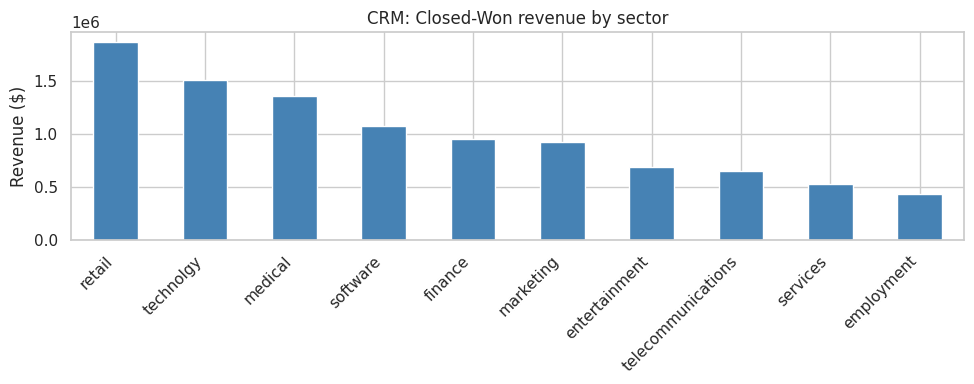

,deals_won,revenue,avg_deal
sector,,,
retail,799,1867528.0,2337.0
technolgy,671,1515487.0,2259.0
medical,592,1359595.0,2297.0
software,450,1077934.0,2395.0
finance,375,950908.0,2536.0
marketing,404,922321.0,2283.0
entertainment,260,689007.0,2650.0
telecommunications,285,653574.0,2293.0
services,223,533006.0,2390.0


In [24]:
# Won revenue by sector — the CRM's own view of where money comes from
won = crm[crm['deal_stage'] == 'Won']

sector_rev = won.groupby('sector').agg(
    deals_won=('opportunity_id', 'count'),
    revenue=('close_value', 'sum'),
    avg_deal=('close_value', 'mean'),
).sort_values('revenue', ascending=False).round(0)

fig, ax = plt.subplots(figsize=(10, 4))
sector_rev['revenue'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('CRM: Closed-Won revenue by sector')
ax.set_ylabel('Revenue ($)')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

sector_rev

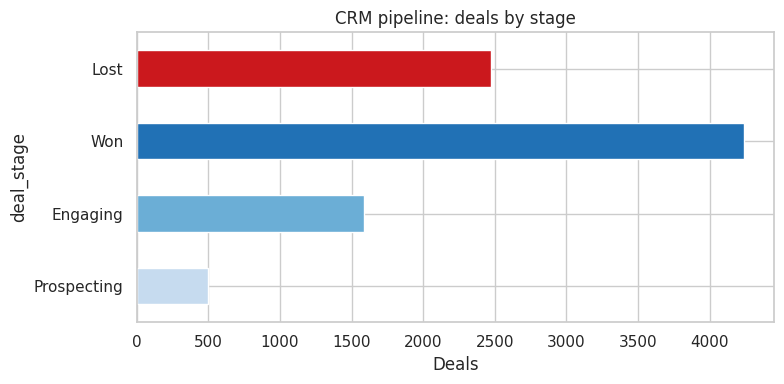

Win rate among resolved deals: 63.2%


In [25]:
# Funnel view
funnel = pipeline['deal_stage'].value_counts().reindex(['Prospecting', 'Engaging', 'Won', 'Lost'])

fig, ax = plt.subplots(figsize=(8, 4))
funnel.plot(kind='barh', ax=ax, color=['#c6dbef', '#6baed6', '#2171b5', '#cb181d'])
ax.set_title('CRM pipeline: deals by stage')
ax.set_xlabel('Deals')
plt.tight_layout()
plt.show()

resolved = pipeline[pipeline['deal_stage'].isin(['Won', 'Lost'])]
print(f"Win rate among resolved deals: {(resolved['deal_stage'] == 'Won').mean():.1%}")

---

# Part 3 — Side-by-side: where these two systems disagree

Now we compare the two systems' *vocabularies and structures* — still without joining.

In [26]:
print("=" * 62)
print("STRUCTURAL COMPARISON")
print("=" * 62)

comparison = pd.DataFrame({
    'Ad Platform': [
        'Single flat CSV',
        '1,800 rows',
        'date × platform × campaign_type × industry × country',
        'None — no ID column exists',
        '5 values (E-commerce, EdTech, Fintech, Healthcare, SaaS)',
        'Pre-aggregated by the platform',
        'Marketing',
    ],
    'CRM': [
        'Relational: 4 linked tables',
        '8,800 deals / 85 accounts',
        'One sales opportunity',
        'opportunity_id (unique), account (FK)',
        '10 values (finance, medical, software, ...)',
        'Row-level, one record per deal',
        'Sales',
    ],
}, index=['Structure', 'Volume', 'Grain', 'Identifiers',
          'Industry vocabulary', 'Aggregation level', 'Owning team'])

comparison

STRUCTURAL COMPARISON


,Ad Platform,CRM
Structure,Single flat CSV,Relational: 4 linked tables
Volume,"1,800 rows","8,800 deals / 85 accounts"
Grain,date × platform × campaign_type × industry × c...,One sales opportunity
Identifiers,None — no ID column exists,"opportunity_id (unique), account (FK)"
Industry vocabulary,"5 values (E-commerce, EdTech, Fintech, Healthc...","10 values (finance, medical, software, ...)"
Aggregation level,Pre-aggregated by the platform,"Row-level, one record per deal"
Owning team,Marketing,Sales


In [27]:
ads_ind = sorted(ads['industry'].unique())
crm_sec = sorted(accounts['sector'].unique())

print("Ads 'industry':  ", ads_ind)
print("CRM 'sector':    ", crm_sec)

exact_overlap = set(ads_ind) & set(crm_sec)
print("\nExact string matches:", exact_overlap or "NONE — zero values match")

# Case-insensitive attempt
ci_overlap = {a for a in ads_ind for c in crm_sec if a.lower() == c.lower()}
print("Case-insensitive matches:", ci_overlap or "NONE")

Ads 'industry':   ['E-commerce', 'EdTech', 'Fintech', 'Healthcare', 'SaaS']
CRM 'sector':     ['employment', 'entertainment', 'finance', 'marketing', 'medical', 'retail', 'services', 'software', 'technolgy', 'telecommunications']

Exact string matches: NONE — zero values match
Case-insensitive matches: NONE


### Finding #3 — the industry taxonomies share zero values

Not one value matches, even ignoring case. These are not two spellings of the same taxonomy;
they are two *different taxonomies* describing overlapping reality:

- The ads vocabulary is **product-category oriented** — how a marketer segments an audience.
- The CRM vocabulary is **firmographic** — how a salesperson describes a company.

Some pairs are semantically close (`Fintech`↔`finance`, `Healthcare`↔`medical`,
`SaaS`↔`software`), but the mapping is neither obvious nor one-to-one, and at least one ads
value (`EdTech`) has no CRM counterpart at all.

**Important:** fuzzy string matching will not solve this. `thefuzz` compares *spelling*, and
`Healthcare` vs `medical` share almost no characters. This needs a **semantic crosswalk built
by hand** — which is exactly the kind of institutional knowledge that should live in a shared
reference table and usually doesn't.

In [28]:
# Demonstrate that fuzzy matching fails here, rather than just asserting it
try:
    from thefuzz import process, fuzz

    # Deliberately NO score threshold here. A threshold would imply the score is
    # informative; the finding in notebook 02 is that it isn't. Print the score and the
    # human-correct answer side by side and let the reader see they don't correlate.
    human_map = {'Fintech': 'finance', 'Healthcare': 'medical', 'SaaS': 'software',
                 'E-commerce': 'retail', 'EdTech': None}

    print("Best fuzzy match for each ads industry against CRM sectors:\n")
    print(f"  {'ads industry':<12}   {'fuzzy best':<18} {'score':>5}   {'human answer':<12} agree?")
    print("  " + "-" * 62)
    for ind in ads_ind:
        match, score = process.extractOne(ind, crm_sec, scorer=fuzz.token_sort_ratio)
        truth = human_map[ind]
        print(f"  {ind:<12} → {match:<18} {score:>5}   {str(truth):<12} "
              f"{'YES' if match == truth else 'no'}")

    print("\nNote: the one correct pair (Fintech→finance) scores 57, while an incorrect")
    print("pair (EdTech→technolgy) scores 53. The scores do not separate right from wrong.")
except ImportError:
    print("thefuzz not installed — run: pip install thefuzz python-Levenshtein")

Best fuzzy match for each ads industry against CRM sectors:

  ads industry   fuzzy best         score   human answer agree?
  --------------------------------------------------------------
  E-commerce   → services              44   retail       no
  EdTech       → technolgy             53   None         no
  Fintech      → finance               57   finance      YES
  Healthcare   → software              44   medical      no
  SaaS         → services              33   software     no

Note: the one correct pair (Fintech→finance) scores 57, while an incorrect
pair (EdTech→technolgy) scores 53. The scores do not separate right from wrong.


In [29]:
# The date overlap problem
ads_start, ads_end = ads['date'].min(), ads['date'].max()
crm_start = pipeline['engage_date'].min()
crm_end = pipeline['close_date'].max()

print(f"Ads data:  {ads_start.date()} → {ads_end.date()}")
print(f"CRM data:  {crm_start.date()} → {crm_end.date()}")

overlap_start = max(ads_start, crm_start)
overlap_end = min(ads_end, crm_end)
overlap_days = (overlap_end - overlap_start).days

print(f"\nOverlapping days: {max(0, overlap_days)}")
print(f"Gap between CRM end and ads start: {(ads_start - crm_end).days:,} days "
      f"(~{(ads_start - crm_end).days / 365.25:.1f} years)")

Ads data:  2024-01-01 → 2024-12-30
CRM data:  2016-10-20 → 2017-12-31

Overlapping days: 0
Gap between CRM end and ads start: 2,192 days (~6.0 years)


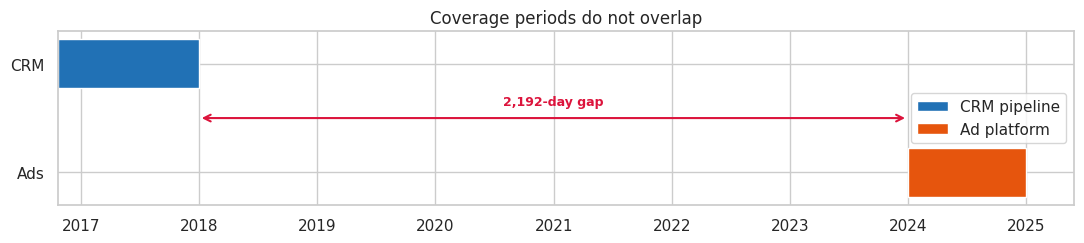

In [30]:
fig, ax = plt.subplots(figsize=(11, 2.6))

ax.barh(1, (crm_end - crm_start).days, left=crm_start, height=0.45,
        color='#2171b5', label='CRM pipeline')
ax.barh(0, (ads_end - ads_start).days, left=ads_start, height=0.45,
        color='#e6550d', label='Ad platform')

ax.set_yticks([0, 1])
ax.set_yticklabels(['Ads', 'CRM'])
ax.set_title('Coverage periods do not overlap')
ax.legend(loc='center right')
ax.annotate('', xy=(ads_start, 0.5), xytext=(crm_end, 0.5),
            arrowprops=dict(arrowstyle='<->', color='crimson', lw=1.5))
ax.text(crm_end + (ads_start - crm_end) / 2, 0.62,
        f'{(ads_start - crm_end).days:,}-day gap',
        ha='center', color='crimson', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

### Finding #4 — the coverage periods do not overlap at all

Ads data covers 2024. CRM data covers late 2016 through 2017. There is **not a single shared
day**.

This eliminates an entire family of analyses: no time-lagged attribution, no "spend in week N →
deals closed in week N+6", no seasonality comparison. Those are the *standard* approaches to
marketing attribution, and none of them are available.

We will address this explicitly with a documented assumption in notebook 02 rather than
quietly ignoring it. Pretending the dates align would be the single worst thing we could do
here — it would produce output that looks like analysis and means nothing.

---

# Summary of findings

| # | Finding | Consequence |
|---|---------|-------------|
| 1 | Ads data has **no identifier column** of any kind | Individual-level attribution is impossible; only aggregate joins available |
| 2 | **16% of CRM deals** have a null `account`, but **0%** of *closed* deals do | Constrains open-pipeline analysis only; all closed revenue remains attributable |
| 3 | Industry taxonomies share **zero values**; fuzzy matching fails | Requires a hand-built semantic crosswalk |
| 4 | Date ranges have **zero overlap** (~6-year gap) | All time-based attribution methods unavailable |
| 5 | CRM has no channel/platform field | Cannot tell which ad platform sourced a deal, even in principle |
| 6 | Grains differ: aggregate rows vs. individual deals | Join must happen at an aggregated level both sides can reach |

### The one available join path

Given the above, the *only* dimension the two systems share any conceptual overlap on is
**industry / sector**. That is the join key by elimination — not because it is good, but because
it is the only one that exists.

That is worth stating plainly, because it sets the expectation for notebook 02: we are about to
attempt a join we already know is weak, in order to measure exactly how weak it is.

### What each system does well

Neither dataset is bad. The ads export is clean, complete, and internally consistent. The CRM
has proper referential integrity and a sensible relational schema. **The failure is entirely at
the seam between them** — which is the characteristic signature of an organisational problem
rather than a technical one. No one owns the interface between marketing and sales data.

---

**Next:** `02_naive_join.ipynb` — attempt the join with no reconciliation and quantify the
match-rate gap.

In [31]:
# Persist typed/enriched versions for the next notebook
import os
os.makedirs('../data/clean', exist_ok=True)

ads.to_parquet('../data/clean/ads_typed.parquet', index=False)
crm.to_parquet('../data/clean/crm_enriched.parquet', index=False)

print("Saved:")
print("  data/clean/ads_typed.parquet     ", ads.shape)
print("  data/clean/crm_enriched.parquet  ", crm.shape)

Saved:
  data/clean/ads_typed.parquet      (1800, 14)
  data/clean/crm_enriched.parquet   (8800, 12)
